<a href="https://colab.research.google.com/github/yinyue31/BA820-Team6-Project/blob/main/BA820_Team6_EDA_Pet_Cats_UK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving cats_uk_reference.csv to cats_uk_reference (1).csv
Saving cats_uk.csv to cats_uk (1).csv


In [ ]:
import os
print(os.listdir("/content"))

['.config', 'cats_uk_reference (1).csv', 'cats_uk.csv', 'cats_uk_reference.csv', 'cats_uk (1).csv', 'sample_data']


In [ ]:
import pandas as pd

events = pd.read_csv("/content/cats_uk.csv")
ref    = pd.read_csv("/content/cats_uk_reference.csv")

print(events.shape)
print(ref.shape)

(18215, 11)
(101, 16)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Events columns:", events.columns.tolist())
print("Ref columns   :", ref.columns.tolist())

Events columns: ['tag_id', 'event_id', 'visible', 'timestamp', 'location_long', 'location_lat', 'ground_speed', 'height_above_ellipsoid', 'algorithm_marked_outlier', 'manually_marked_outlier', 'study_name']
Ref columns   : ['tag_id', 'animal_id', 'animal_taxon', 'deploy_on_date', 'deploy_off_date', 'hunt', 'prey_p_month', 'animal_reproductive_condition', 'animal_sex', 'hrs_indoors', 'n_cats', 'food_dry', 'food_wet', 'food_other', 'study_site', 'age_years']


# Figure 1. Distribution of GPS event counts per cat

This figure examines the distribution of tracking coverage across individual cats.
The large variation in event counts indicates that some cats are observed much more frequently than others, suggesting uneven data coverage.
This raises questions about how stable individual-level behavioral summaries may be for sparsely tracked cats.

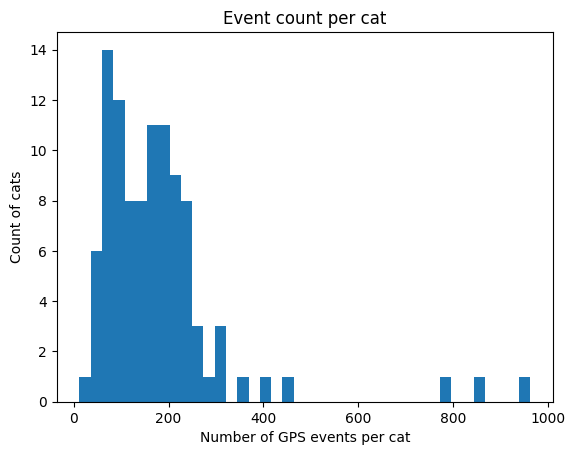

count    101.000000
mean     180.346535
std      146.280582
min       12.000000
25%      100.000000
50%      155.000000
75%      214.000000
max      963.000000
dtype: float64


In [ ]:
id_col = "tag_id"

events_per_cat = events.groupby(id_col).size()

plt.figure()
plt.hist(events_per_cat.values, bins=40)
plt.xlabel("Number of GPS events per cat")
plt.ylabel("Count of cats")
plt.title("Event count per cat")
plt.show()

print(events_per_cat.describe())

# Figure 2. Distribution of ground speed


This figure explores the overall distribution of movement intensity across all GPS events.
The strongly right-skewed shape shows that most movements occur at low speeds, while a small number of events exhibit extremely high speeds.
Such a long-tailed distribution suggests the presence of multiple movement regimes rather than a single typical behavior.

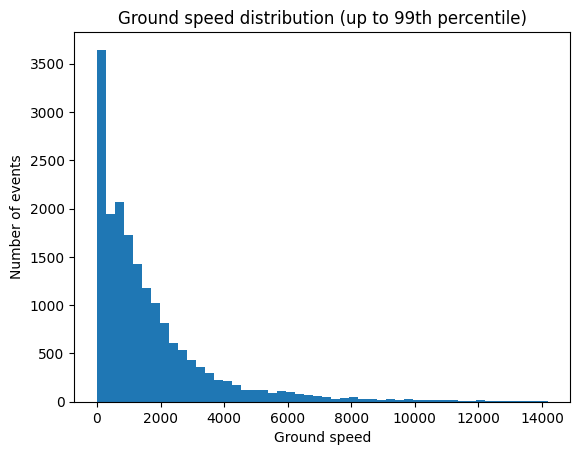

In [ ]:
spd_col = "ground_speed"

spd = events[spd_col].replace([np.inf, -np.inf], np.nan).dropna()

# Figure 2: histogram
import numpy as np
import matplotlib.pyplot as plt

spd = events["ground_speed"].replace([np.inf, -np.inf], np.nan).dropna()

upper = spd.quantile(0.99)

plt.figure()
plt.hist(spd[spd <= upper], bins=50)
plt.xlabel("Ground speed")
plt.ylabel("Number of events")
plt.title("Ground speed distribution (up to 99th percentile)")
plt.show()

# Figure 3. Ground speed boxplot with extreme values

This boxplot highlights the spread and extreme values of ground speed.
The compression of the central distribution alongside numerous high-value outliers indicates that extreme events dominate the scale of the data.
This observation suggests that summary statistics such as the mean may be insufficient to characterize movement behavior.

99th percentile: 14214.960000000021
Max speed: 277092


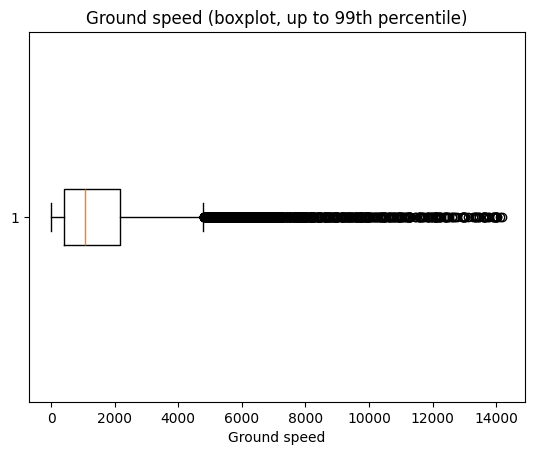

99th percentile: 14214.960000000021


In [ ]:
print("99th percentile:", upper)
print("Max speed:", spd.max())

import numpy as np
import matplotlib.pyplot as plt

spd = events["ground_speed"].replace([np.inf, -np.inf], np.nan).dropna()

upper = spd.quantile(0.99)

plt.figure()
plt.boxplot(
    spd[spd <= upper],
    vert=False,
    showfliers=True
)
plt.xlabel("Ground speed")
plt.title("Ground speed (boxplot, up to 99th percentile)")
plt.show()

print("99th percentile:", upper)

# Figure 4. Hourly distribution of GPS events

This figure examines how GPS events are distributed across hours of the day.
Activity levels are not uniform over time, indicating temporal structure in movement behavior.
The observed pattern suggests that cats may follow different daily activity rhythms, which are not captured by aggregate measures alone.

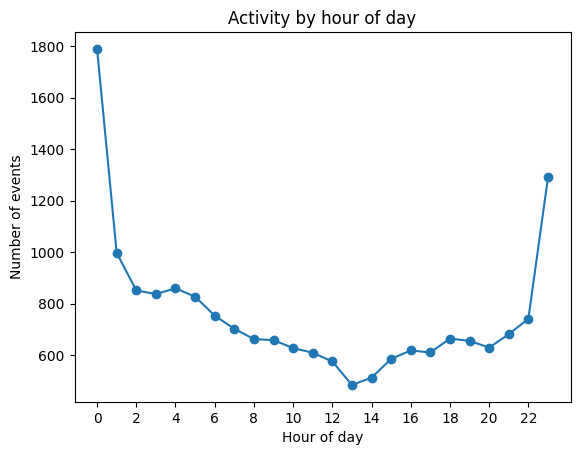

In [ ]:
events["timestamp"] = pd.to_datetime(events["timestamp"], errors="coerce")
events["hour"] = events["timestamp"].dt.hour

hour_counts = events["hour"].value_counts().sort_index()

plt.figure()
plt.plot(hour_counts.index, hour_counts.values, marker="o")
plt.xticks(range(0, 24, 2))
plt.xlabel("Hour of day")
plt.ylabel("Number of events")
plt.title("Activity by hour of day")
plt.show()

# Figure 5. Spatial movement patterns for selected cats

These spatial scatter plots provide an intuitive view of individual movement ranges.
Clear differences are observed across cats, with some showing highly localized movement and others exhibiting much broader spatial dispersion.
This visual heterogeneity suggests that spatial behavior varies substantially across individuals.

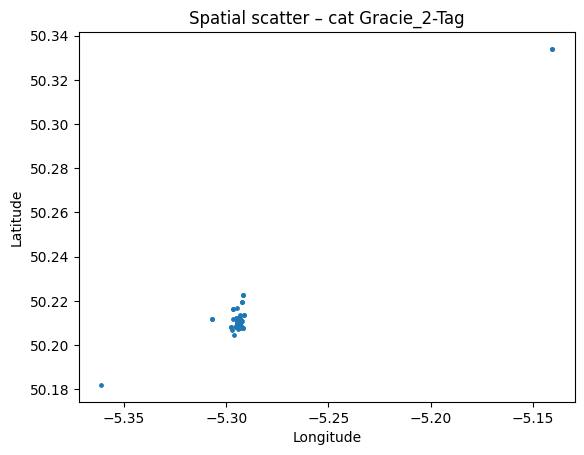

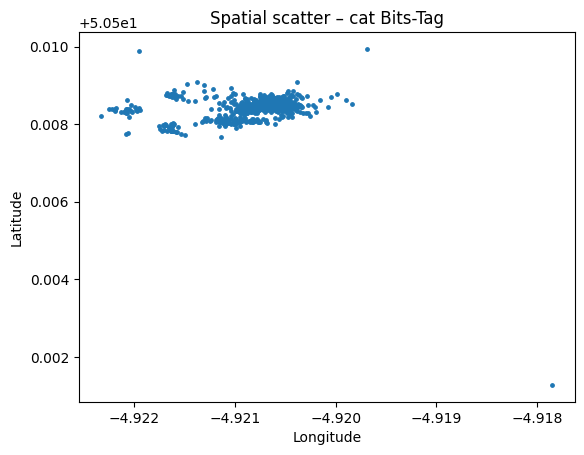

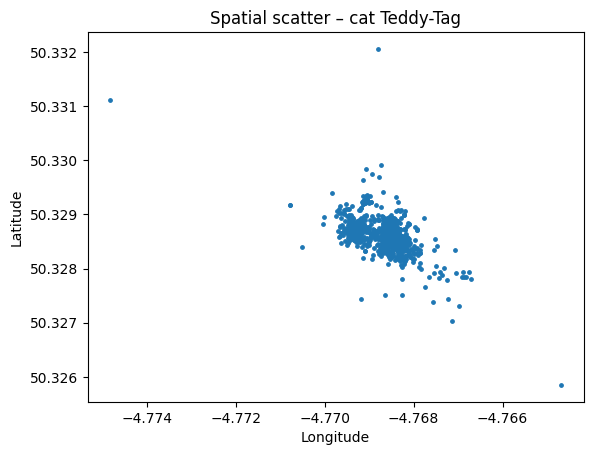

In [ ]:
lat_col = "location_lat"
lon_col = "location_long"

top_cats = events_per_cat.sort_values(ascending=False).head(3).index

for cat in top_cats:
    sub = events.loc[events[id_col] == cat, [lat_col, lon_col]].dropna()
    if len(sub) > 4000:
        sub = sub.sample(4000, random_state=42)

    plt.figure()
    plt.scatter(sub[lon_col], sub[lat_col], s=6)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title(f"Spatial scatter – cat {cat}")
    plt.show()

# Figure 6. Ground speed comparison between outlier and non-outlier events

This figure compares movement speeds between algorithm-marked outlier and non-outlier events.
While outlier events tend to be associated with higher speeds, substantial overlap remains between the two groups.
This raises questions about whether algorithmic outlier flags fully capture all extreme or unusual movement behaviors.

/tmp/ipython-input-797703332.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


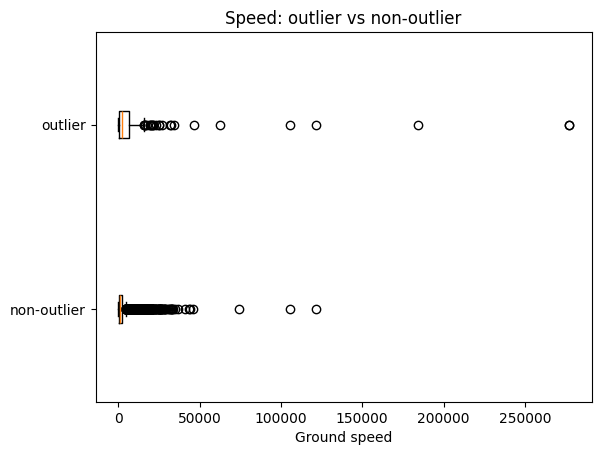

Outlier share: 0.011583859456491902


In [ ]:
out_col = "algorithm_marked_outlier"

if out_col in events.columns:
    sub = events[[out_col, spd_col]].dropna()

    plt.figure()
    plt.boxplot(
        [
            sub.loc[sub[out_col] == False, spd_col],
            sub.loc[sub[out_col] == True, spd_col]
        ],
        vert=False,
        labels=["non-outlier", "outlier"],
        showfliers=True
    )
    plt.xlabel("Ground speed")
    plt.title("Speed: outlier vs non-outlier")
    plt.show()

    print("Outlier share:", sub[out_col].mean())
else:
    print("No outlier column found – skip this step.")

# Figure 7. Distribution of individual-level background characteristics

This figure summarizes the distributions of selected individual-level characteristics.
The wide dispersion across variables such as age, indoor time, and hunting activity indicates strong heterogeneity among cats.
These differences suggest that background characteristics may help contextualize observed movement patterns in later analysis.

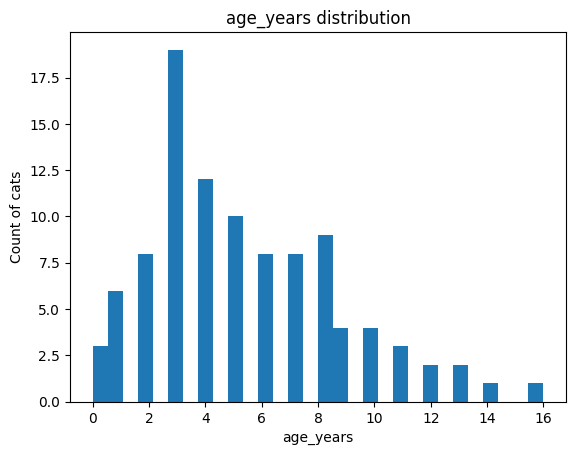

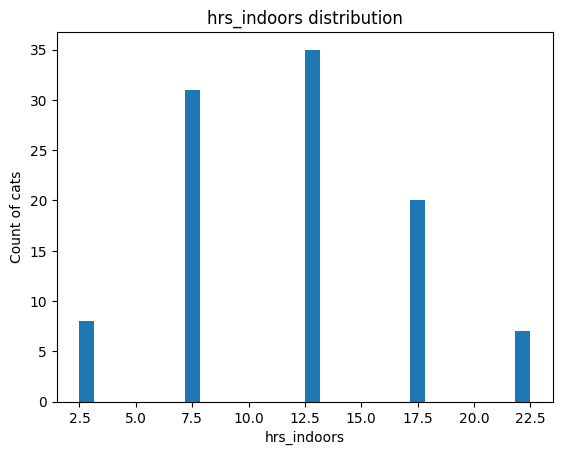

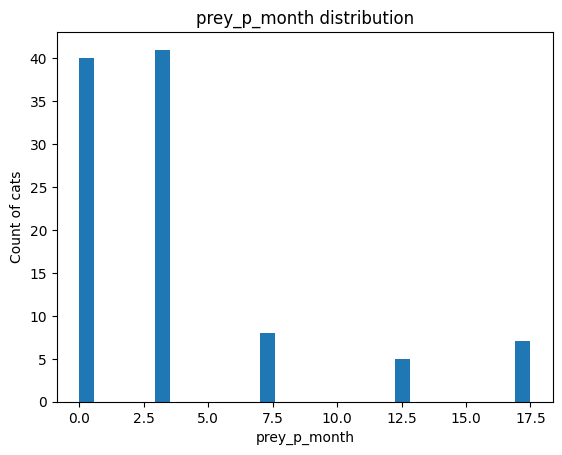

In [ ]:
ref_cols = ["age_years", "hrs_indoors", "prey_p_month"]

for c in ref_cols:
    if c in ref.columns:
        plt.figure()
        plt.hist(ref[c].dropna(), bins=30)
        plt.xlabel(c)
        plt.ylabel("Count of cats")
        plt.title(f"{c} distribution")
        plt.show()